In [1]:
from loaddata_new_reward import *

In [2]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt

In [3]:
from loaddata_new_reward import (
    load_paper_rad_data,
    build_paper_features,
    make_state_tensors_all,
    compute_pnl,
    PaperA2CTrainer,
    build_envs_from_state_dict_newreward,
    build_cov_lookup_newreward,
    build_a2c_table3_comparison_wide,
)


#### Import data

In [4]:
DATA_ROOT = r"data/CLC"

STATE_FEATURES = [
    "close_norm",
    "ret_1m",
    "ret_2m",
    "ret_3m",
    "ret_1y",
    "macd_8_24",
    "macd_16_48",
    "macd_32_96",
    "rsi_30",
]

TRAIN_END_1 = "2010-12-31"
TEST_START_1 = "2011-01-01"
TEST_END_1 = "2015-12-31"

TRAIN_END_2 = "2015-12-31"
TEST_START_2 = "2016-01-01"
TEST_END_2 = "2019-12-31"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [5]:
data_dict, panel, missing = load_paper_rad_data(
    DATA_ROOT,
    start="2005-01-01",
    end="2019-12-31"
)

print("Loaded tickers:", len(data_dict))
print("Missing tickers:", missing)
print(panel.head())

Loaded tickers: 50
Missing tickers: []
        date    open    high     low   close  volume  open_interest ticker
0 2005-01-03  1848.0  1865.0  1831.0  1832.0    4759         117684     CC
1 2005-01-04  1830.0  1841.0  1821.0  1827.0    7117         118137     CC
2 2005-01-05  1821.0  1848.0  1820.0  1831.0    5350         118335     CC
3 2005-01-06  1824.0  1831.0  1807.0  1817.0    8218         117911     CC
4 2005-01-07  1809.0  1813.0  1764.0  1767.0   14843         119415     CC


In [6]:
feature_dict, feature_panel = build_paper_features(data_dict, dropna=False)

print(feature_panel.head())
print(feature_panel.columns.tolist())

        date ticker   open   high    low  close  volume  open_interest  \
0 2005-01-03     AN  59.27  59.33  58.47  59.00   14080          64957   
1 2005-01-04     AN  58.77  59.03  57.77  57.87   15875          66759   
2 2005-01-05     AN  57.91  58.15  57.49  57.92   12408          67640   
3 2005-01-06     AN  57.91  57.95  57.37  57.55   10195          66989   
4 2005-01-07     AN  57.68  58.12  57.10  57.23   15414          64094   

   ret_1d  ewm_vol_60  ...  ret_1y_raw  ret_1m  ret_2m  ret_3m  ret_1y  \
0     NaN         NaN  ...         NaN     NaN     NaN     NaN     NaN   
1   -1.13         NaN  ...         NaN     NaN     NaN     NaN     NaN   
2    0.05         NaN  ...         NaN     NaN     NaN     NaN     NaN   
3   -0.37         NaN  ...         NaN     NaN     NaN     NaN     NaN   
4   -0.32         NaN  ...         NaN     NaN     NaN     NaN     NaN   

   macd_8_24  macd_16_48  macd_32_96  macd_avg  rsi_30  
0        NaN         NaN         NaN       NaN     Na

#### A2C-only setup

The baseline strategies are not evaluated in this version. The notebook keeps only the A2C workflow and its evaluation tables.

In [7]:
feature_train_1 = {}
feature_test_1 = {}
feature_train_2 = {}
feature_test_2 = {}

for ticker, df in feature_dict.items():
    feature_train_1[ticker] = df[df["date"] <= TRAIN_END_1].copy()
    feature_test_1[ticker]  = df[(df["date"] >= TEST_START_1) & (df["date"] <= TEST_END_1)].copy()

    feature_train_2[ticker] = df[df["date"] <= TRAIN_END_2].copy()
    feature_test_2[ticker]  = df[(df["date"] >= TEST_START_2) & (df["date"] <= TEST_END_2)].copy()

print("Train/test split done.")

Train/test split done.


In [8]:
state_train_1 = make_state_tensors_all(feature_train_1, feature_cols=STATE_FEATURES, window=60)
state_test_1  = make_state_tensors_all(feature_test_1,  feature_cols=STATE_FEATURES, window=60)

state_train_2 = make_state_tensors_all(feature_train_2, feature_cols=STATE_FEATURES, window=60)
state_test_2  = make_state_tensors_all(feature_test_2,  feature_cols=STATE_FEATURES, window=60)

print("State tensors built.")

State tensors built.


In [9]:
PAPER_TICKERS_BY_ASSET_CLASS = {
    "Commodity": ["CC","DA","GI","JO","KC","KW","LB","NR","SB","ZA","ZC","ZF","ZG","ZH","ZI","ZK","ZL","ZN","ZO","ZP","ZR","ZT","ZU","ZW","ZZ"],
    "Equity Index": ["CA","EN","ER","ES","LX","MD","SC","SP","XU","XX","YM"],
    "Fixed Income": ["DT","FB","TY","UB","US"],
    "FX": ["AN","BN","CN","DX","FN","JN","MP","NK","SN"],
}
PAPER_TICKERS_BY_ASSET_CLASS["All"] = sorted(sum(PAPER_TICKERS_BY_ASSET_CLASS.values(), []))
BP = 0.0020
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LR_ACTOR = 1e-4       # paper Table 1
LR_CRITIC = 1e-3      # paper Table 1
GAMMA = 0.3           # paper Table 1
BATCH_SIZE = 128      # paper Table 1
BP = 0.0020           # paper Table 1
MU = 1.0              # paper Eq.4 text
WINDOW = 60           # past 60 observations in state
HIDDEN_SIZES = [64, 32]   # paper Section 4.3
LEAKY_RELU_SLOPE = 0.01

In [10]:
a2c_models_period1 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    valid_tickers = []
    for ticker in tickers:
        if ticker not in state_train_1:
            continue

        X = state_train_1[ticker]["X"]
        aligned_df = state_train_1[ticker]["aligned_df"]

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        valid_tickers.append(ticker)

    print(asset_class, "valid tickers (period 1):", valid_tickers)

    envs = build_envs_from_state_dict_newreward(
        state_train_1,
        tickers=valid_tickers,
        sigma_target=0.064,# baseline assumption
        bp=BP,
        mu=MU,
    )

    lambda_corr = 0.01
    cov_lookup = build_cov_lookup_newreward(
        state_dict=state_train_1,
        tickers=valid_tickers,
        lookback=60,
        ret_col="ret_1d",
    )

    if len(envs) == 0:
        print(f"{asset_class}: no envs in period 1")
        continue

    rollout_steps = max(1, round(BATCH_SIZE / len(envs)))
    effective_batch = rollout_steps * len(envs)

    print(
        f"{asset_class}: envs={len(envs)}, "
        f"rollout_steps={rollout_steps}, "
        f"effective_batch={effective_batch}"
    )

    trainer = PaperA2CTrainer(
        n_features=len(STATE_FEATURES),
        device=DEVICE
    )

    ckpt_path = f"a2c_{asset_class}_period1_newreward.pt"

    start_update = 0
    if os.path.exists(ckpt_path):
        ckpt = trainer.load_checkpoint(ckpt_path, map_location=DEVICE)
        start_update = ckpt.get("extra_state", {}).get("update_idx", 0)
        print(f"resumed from {ckpt_path}, start_update={start_update}")

    # ===== Early Stopping Training Loop =====
    max_total_updates = 2000
    chunk_updates = 50
    patience = 5
    improve_tol = 1e-4

    best_reward = -np.inf
    no_improve_rounds = 0
    total_updates = start_update

    while total_updates < max_total_updates:

        print(f"\n=== {asset_class}: training chunk starting at {total_updates} ===")

        trainer.fit_newreward(
            envs=envs,
            n_updates=chunk_updates,
            rollout_steps=rollout_steps,
            log_every=10,
            checkpoint_path=ckpt_path,
            checkpoint_every=10,
            start_update=total_updates,
            cov_lookup=cov_lookup,
            lambda_corr=lambda_corr,
        )

        total_updates += chunk_updates

        recent_rewards = [x["avg_reward"] for x in trainer.train_log[-chunk_updates:]]
        mean_reward = np.mean(recent_rewards)

        print(f"{asset_class}: mean_reward (last {chunk_updates}) = {mean_reward:.6f}")

        if mean_reward > best_reward + improve_tol:
            best_reward = mean_reward
            no_improve_rounds = 0
            print("improvement")
        else:
            no_improve_rounds += 1
            print(f"no improvement ({no_improve_rounds}/{patience})")

        if no_improve_rounds >= patience:
            print(f" Early stopping triggered for {asset_class}")
            break

    a2c_models_period1[asset_class] = trainer

print("A2C period 1 training done.")

Commodity valid tickers (period 1): ['CC', 'DA', 'GI', 'JO', 'KC', 'KW', 'LB', 'NR', 'SB', 'ZA', 'ZC', 'ZF', 'ZG', 'ZI', 'ZK', 'ZL', 'ZN', 'ZO', 'ZP', 'ZR', 'ZT', 'ZW', 'ZZ']
Commodity: envs=23, rollout_steps=6, effective_batch=138
resumed from a2c_Commodity_period1_newreward.pt, start_update=2000
Equity Index valid tickers (period 1): ['CA', 'EN', 'ER', 'ES', 'LX', 'MD', 'SC', 'SP', 'XU', 'XX', 'YM']
Equity Index: envs=11, rollout_steps=12, effective_batch=132
resumed from a2c_Equity Index_period1_newreward.pt, start_update=2000
Fixed Income valid tickers (period 1): ['DT', 'FB', 'TY', 'UB']
Fixed Income: envs=4, rollout_steps=32, effective_batch=128
resumed from a2c_Fixed Income_period1_newreward.pt, start_update=2000
FX valid tickers (period 1): ['AN', 'BN', 'CN', 'DX', 'FN', 'JN', 'MP', 'NK', 'SN']
FX: envs=9, rollout_steps=14, effective_batch=126
resumed from a2c_FX_period1_newreward.pt, start_update=2000
A2C period 1 training done.


In [11]:
pnl_a2c_by_ticker_period1 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    if asset_class not in a2c_models_period1:
        continue

    trainer = a2c_models_period1[asset_class]
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    for ticker in tickers:
        if ticker not in state_test_1:
            continue

        X = state_test_1[ticker]["X"]
        aligned_df = state_test_1[ticker]["aligned_df"].copy()

        if len(X) == 0 or len(aligned_df) == 0:
            continue

        with torch.no_grad():
            x_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            actions = trainer.actor.deterministic_action(x_tensor).squeeze(-1).cpu().numpy()

        aligned_df["a2c_signal"] = actions
        pnl_df = compute_pnl(aligned_df, signal_col="a2c_signal", dropna=True)

        pnl_a2c_by_ticker_period1[ticker] = pnl_df

print("A2C period 1 test pnl done.")

A2C period 1 test pnl done.


In [12]:
a2c_models_period2 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    valid_tickers = []
    for ticker in tickers:
        if ticker not in state_train_2:
            continue

        X = state_train_2[ticker]["X"]
        aligned_df = state_train_2[ticker]["aligned_df"]

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        valid_tickers.append(ticker)

    print(asset_class, "valid tickers (period 2):", valid_tickers)

    envs = build_envs_from_state_dict_newreward(
        state_train_2,
        tickers=valid_tickers,
        sigma_target=0.064,# baseline assumption
        bp=BP,
        mu=MU,
    )

    lambda_corr = 0.01
    cov_lookup = build_cov_lookup_newreward(
        state_dict=state_train_2,
        tickers=valid_tickers,
        lookback=60,
        ret_col="ret_1d",
    )

    if len(envs) == 0:
        print(f"{asset_class}: no envs in period 2")
        continue

    rollout_steps = max(1, round(BATCH_SIZE / len(envs)))
    effective_batch = rollout_steps * len(envs)

    print(
        f"{asset_class}: envs={len(envs)}, "
        f"rollout_steps={rollout_steps}, "
        f"effective_batch={effective_batch}"
    )

    trainer = PaperA2CTrainer(
        n_features=len(STATE_FEATURES),
        device=DEVICE
    )

    ckpt_path = f"a2c_{asset_class}_period2_newreward.pt"

    start_update = 0
    if os.path.exists(ckpt_path):
        ckpt = trainer.load_checkpoint(ckpt_path, map_location=DEVICE)
        start_update = ckpt.get("extra_state", {}).get("update_idx", 0)
        print(f"resumed from {ckpt_path}, start_update={start_update}")

    # ===== Early Stopping Training Loop =====
    max_total_updates = 2000
    chunk_updates = 50
    patience = 5
    improve_tol = 1e-4

    best_reward = -np.inf
    no_improve_rounds = 0
    total_updates = start_update

    while total_updates < max_total_updates:

        print(f"\n=== {asset_class}: training chunk starting at {total_updates} ===")

        trainer.fit_newreward(
            envs=envs,
            n_updates=chunk_updates,
            rollout_steps=rollout_steps,
            log_every=10,
            checkpoint_path=ckpt_path,
            checkpoint_every=10,
            start_update=total_updates,
            cov_lookup=cov_lookup,
            lambda_corr=lambda_corr,
        )

        total_updates += chunk_updates

        recent_rewards = [x["avg_reward"] for x in trainer.train_log[-chunk_updates:]]
        mean_reward = np.mean(recent_rewards)

        print(f"{asset_class}: mean_reward (last {chunk_updates}) = {mean_reward:.6f}")

        if mean_reward > best_reward + improve_tol:
            best_reward = mean_reward
            no_improve_rounds = 0
            print("improvement")
        else:
            no_improve_rounds += 1
            print(f"no improvement ({no_improve_rounds}/{patience})")

        if no_improve_rounds >= patience:
            print(f"Early stopping triggered for {asset_class}")
            break

    a2c_models_period2[asset_class] = trainer

print("A2C period 2 training done.")

Commodity valid tickers (period 2): ['CC', 'DA', 'GI', 'JO', 'KC', 'KW', 'LB', 'NR', 'SB', 'ZA', 'ZC', 'ZF', 'ZG', 'ZI', 'ZK', 'ZL', 'ZN', 'ZO', 'ZP', 'ZR', 'ZT', 'ZW', 'ZZ']
Commodity: envs=23, rollout_steps=6, effective_batch=138
resumed from a2c_Commodity_period2_newreward.pt, start_update=2000
Equity Index valid tickers (period 2): ['CA', 'EN', 'ER', 'ES', 'LX', 'MD', 'SC', 'SP', 'XU', 'XX', 'YM']
Equity Index: envs=11, rollout_steps=12, effective_batch=132
resumed from a2c_Equity Index_period2_newreward.pt, start_update=2000
Fixed Income valid tickers (period 2): ['DT', 'FB', 'TY', 'UB']
Fixed Income: envs=4, rollout_steps=32, effective_batch=128
resumed from a2c_Fixed Income_period2_newreward.pt, start_update=2000
FX valid tickers (period 2): ['AN', 'BN', 'CN', 'DX', 'FN', 'JN', 'MP', 'NK', 'SN']
FX: envs=9, rollout_steps=14, effective_batch=126
resumed from a2c_FX_period2_newreward.pt, start_update=2000
A2C period 2 training done.


In [13]:
pnl_a2c_by_ticker_period2 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    if asset_class not in a2c_models_period2:
        continue

    trainer = a2c_models_period2[asset_class]
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    for ticker in tickers:
        if ticker not in state_test_2:
            continue

        X = state_test_2[ticker]["X"]
        aligned_df = state_test_2[ticker]["aligned_df"].copy()

        if len(X) == 0 or len(aligned_df) == 0:
            continue

        with torch.no_grad():
            x_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            actions = trainer.actor.deterministic_action(x_tensor).squeeze(-1).cpu().numpy()

        aligned_df["a2c_signal"] = actions
        pnl_df = compute_pnl(aligned_df, signal_col="a2c_signal", dropna=True)

        pnl_a2c_by_ticker_period2[ticker] = pnl_df

print("A2C period 2 test pnl done.")

A2C period 2 test pnl done.


In [14]:
pnl_a2c_by_ticker = {}

all_tickers = sorted(set(list(pnl_a2c_by_ticker_period1.keys()) + list(pnl_a2c_by_ticker_period2.keys())))

for ticker in all_tickers:
    parts = []
    if ticker in pnl_a2c_by_ticker_period1:
        parts.append(pnl_a2c_by_ticker_period1[ticker])
    if ticker in pnl_a2c_by_ticker_period2:
        parts.append(pnl_a2c_by_ticker_period2[ticker])

    if len(parts) > 0:
        pnl_a2c_by_ticker[ticker] = (
            pd.concat(parts, ignore_index=True)
            .sort_values("date")
            .reset_index(drop=True)
        )

print("A2C full test pnl done.")

A2C full test pnl done.


In [15]:
pnl_by_model_by_ticker = {
    "A2C": pnl_a2c_by_ticker,
}
print("A2C-only pnl dictionary ready.")

A2C-only pnl dictionary ready.


In [16]:
ticker_to_asset1 = {}

for asset_class, tickers in PAPER_TICKERS_BY_ASSET_CLASS.items():
    if asset_class == "All":
        continue
    label = "Forex" if asset_class == "FX" else asset_class
    for ticker in tickers:
        ticker_to_asset1[ticker] = label

ticker_to_asset1

{'CC': 'Commodity',
 'DA': 'Commodity',
 'GI': 'Commodity',
 'JO': 'Commodity',
 'KC': 'Commodity',
 'KW': 'Commodity',
 'LB': 'Commodity',
 'NR': 'Commodity',
 'SB': 'Commodity',
 'ZA': 'Commodity',
 'ZC': 'Commodity',
 'ZF': 'Commodity',
 'ZG': 'Commodity',
 'ZH': 'Commodity',
 'ZI': 'Commodity',
 'ZK': 'Commodity',
 'ZL': 'Commodity',
 'ZN': 'Commodity',
 'ZO': 'Commodity',
 'ZP': 'Commodity',
 'ZR': 'Commodity',
 'ZT': 'Commodity',
 'ZU': 'Commodity',
 'ZW': 'Commodity',
 'ZZ': 'Commodity',
 'CA': 'Equity Index',
 'EN': 'Equity Index',
 'ER': 'Equity Index',
 'ES': 'Equity Index',
 'LX': 'Equity Index',
 'MD': 'Equity Index',
 'SC': 'Equity Index',
 'SP': 'Equity Index',
 'XU': 'Equity Index',
 'XX': 'Equity Index',
 'YM': 'Equity Index',
 'DT': 'Fixed Income',
 'FB': 'Fixed Income',
 'TY': 'Fixed Income',
 'UB': 'Fixed Income',
 'US': 'Fixed Income',
 'AN': 'Forex',
 'BN': 'Forex',
 'CN': 'Forex',
 'DX': 'Forex',
 'FN': 'Forex',
 'JN': 'Forex',
 'MP': 'Forex',
 'NK': 'Forex',
 'SN

In [17]:
def build__by_asset(pnl_a2c_by_ticker, ticker_to_asset):
    """
    Convert per-ticker A2C reward DataFrames into cumulative reward curves by asset class.

    This uses df['net_pnl'], the reward/PnL recomputed by compute_pnl().
    The curve starts from 0, so it is a cumulative reward curve rather than a wealth index.
    """
    results = {}
    asset_classes = ["Commodity", "Equity Index", "Fixed Income", "Forex"]

    for asset in asset_classes:
        series_list = []

        for ticker, df in pnl_a2c_by_ticker.items():
            if ticker_to_asset.get(ticker) != asset:
                continue
            if df is None or len(df) == 0:
                continue
            if not all(c in df.columns for c in ["date", "net_pnl"]):
                continue

            s = pd.Series(df["net_pnl"].values, index=pd.to_datetime(df["date"]))
            series_list.append(s)

        if series_list:
            port_series = pd.DataFrame(series_list).T.sort_index().mean(axis=1)
            results[asset] = (
                port_series.index.to_numpy(),
                np.cumsum(port_series.fillna(0.0).values),
            )
        else:
            results[asset] = (None, None)

    all_ticker_series = []
    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if not all(c in df.columns for c in ["date", "net_pnl"]):
            continue
        s = pd.Series(df["net_pnl"].values, index=pd.to_datetime(df["date"]))
        all_ticker_series.append(s)

    if all_ticker_series:
        port_series_all = pd.DataFrame(all_ticker_series).T.sort_index().mean(axis=1)
        results["All"] = (
            port_series_all.index.to_numpy(),
            np.cumsum(port_series_all.fillna(0.0).values),
        )
    else:
        results["All"] = (None, None)

    return results

In [18]:
a2c_results = build__by_asset(pnl_a2c_by_ticker, ticker_to_asset1)

a2c_wide = {}
for asset, (dates, curve) in a2c_results.items():
    if dates is None or curve is None:
        continue
    a2c_wide[asset] = pd.Series(curve, index=pd.to_datetime(dates)).sort_index()

a2c_results_wide = pd.DataFrame(a2c_wide)
a2c_results_wide.to_csv("new_reward_a2c_cumulative_reward_wide.csv")
a2c_results_wide.tail()

,Commodity,Equity Index,Fixed Income,Forex,All
2019-12-24,-2.044459,0.702266,4.153620,-1.843422,-0.668983
2019-12-26,-2.028814,0.689113,4.160913,-1.823581,-0.657741
2019-12-27,-1.996101,0.692281,4.197239,-1.775073,-0.628611
2019-12-30,-1.988696,0.706875,4.116555,-1.772972,-0.628036
2019-12-31,-1.990975,0.703874,4.104031,-1.733089,-0.622118


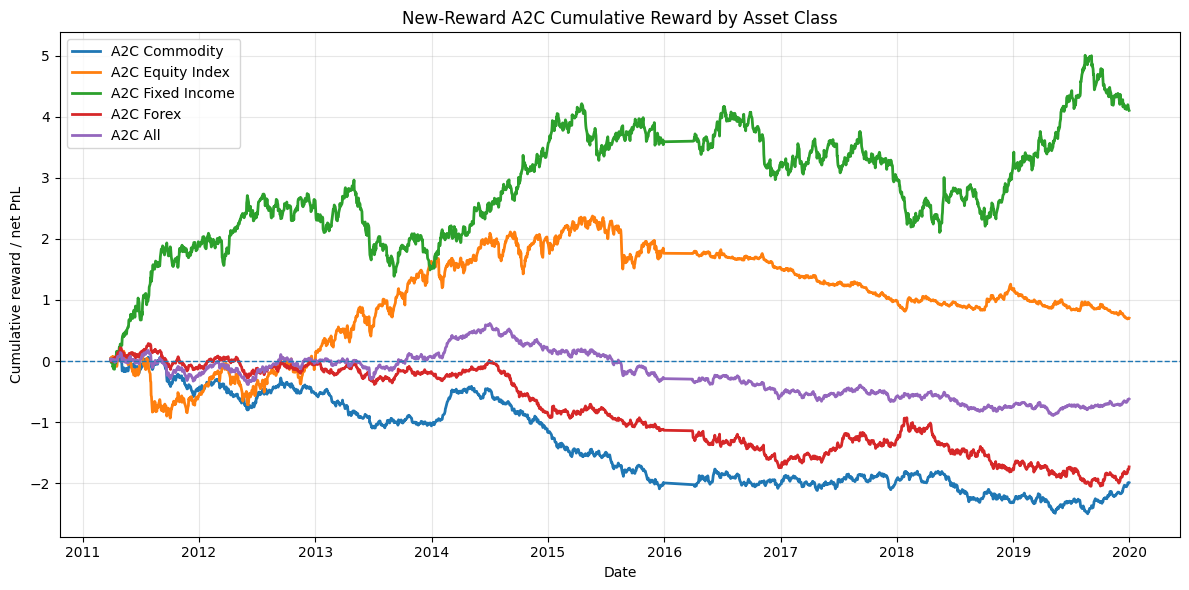

In [26]:
asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]

plt.figure(figsize=(12, 6))

for asset in asset_order:
    dates, curve = a2c_results.get(asset, (None, None))
    if dates is None or curve is None:
        continue

    a2c_curve = pd.Series(curve, index=pd.to_datetime(dates)).sort_index()
    plt.plot(a2c_curve.index, a2c_curve.values, linewidth=2, label=f"A2C {asset}")

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("New-Reward A2C Cumulative Reward by Asset Class")
plt.xlabel("Date")
plt.ylabel("Cumulative reward / net PnL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Transaction cost robustness

This section keeps the trained new-reward A2C signals fixed and recomputes the original evaluation reward under different transaction-cost assumptions.

In [20]:
def build_transaction_cost_robustness(
    pnl_by_ticker,
    ticker_to_asset,
    cost_bps,
    signal_col="a2c_signal",
    sigma_target=0.064,
    mu=1.0,
):
    """
    Recompute A2C evaluation reward under several transaction-cost levels.

    The trained A2C signal is kept fixed. For each cost level, compute_pnl()
    is called again with a different bp value, then cumulative reward curves
    are rebuilt by asset class.
    """
    curves_by_cost = {}
    summary_rows = []

    for cost_bp in cost_bps:
        bp_decimal = cost_bp / 10000.0
        pnl_by_ticker_cost = {}

        for ticker, df in pnl_by_ticker.items():
            if df is None or len(df) == 0:
                continue
            if signal_col not in df.columns:
                continue

            pnl_by_ticker_cost[ticker] = compute_pnl(
                df=df.copy(),
                signal_col=signal_col,
                sigma_target=sigma_target,
                bp=bp_decimal,
                mu=mu,
                dropna=False,
            )

        curves = build__by_asset(pnl_by_ticker_cost, ticker_to_asset)
        curves_by_cost[cost_bp] = curves

        for asset, (dates, curve) in curves.items():
            final_value = np.nan
            if curve is not None and len(curve) > 0:
                final_value = float(pd.Series(curve).dropna().iloc[-1])

            summary_rows.append({
                "cost_bp": cost_bp,
                "asset_class": asset,
                "final_cumulative_reward": final_value,
            })

    summary = pd.DataFrame(summary_rows)
    return curves_by_cost, summary

In [21]:
TC_BPS = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45]

# Reprice the same new-reward A2C signals under each cost level.
# The models are not retrained it is only the bp input in compute_pnl() changes.
tc_robustness_curves, tc_robustness_summary = build_transaction_cost_robustness(
    pnl_by_ticker=pnl_a2c_by_ticker,
    ticker_to_asset=ticker_to_asset1,
    cost_bps=TC_BPS,
    signal_col="a2c_signal",
    sigma_target=0.064,
    mu=MU,
)

tc_summary_wide = (
    tc_robustness_summary
    .pivot(index="cost_bp", columns="asset_class", values="final_cumulative_reward")
    .reset_index()
)

tc_summary_wide.to_csv("new_reward_a2c_transaction_cost_robustness_summary.csv", index=False)
tc_summary_wide

asset_class,cost_bp,All,Commodity,Equity Index,Fixed Income,Forex
0,1,-0.072598,-1.697782,0.973192,6.386073,-1.017417
1,5,-0.194032,-1.764339,0.901220,5.901196,-1.165509
2,10,-0.345825,-1.847536,0.811256,5.295099,-1.350624
3,15,-0.497617,-1.930733,0.721291,4.689002,-1.535739
4,20,-0.649410,-2.013930,0.631327,4.082906,-1.720855
5,25,-0.801202,-2.097127,0.541363,3.476809,-1.905970
6,30,-0.952995,-2.180324,0.451398,2.870712,-2.091085
7,35,-1.104787,-2.263520,0.361434,2.264615,-2.276200
8,40,-1.256580,-2.346717,0.271470,1.658519,-2.461315
9,45,-1.408372,-2.429914,0.181506,1.052422,-2.646430


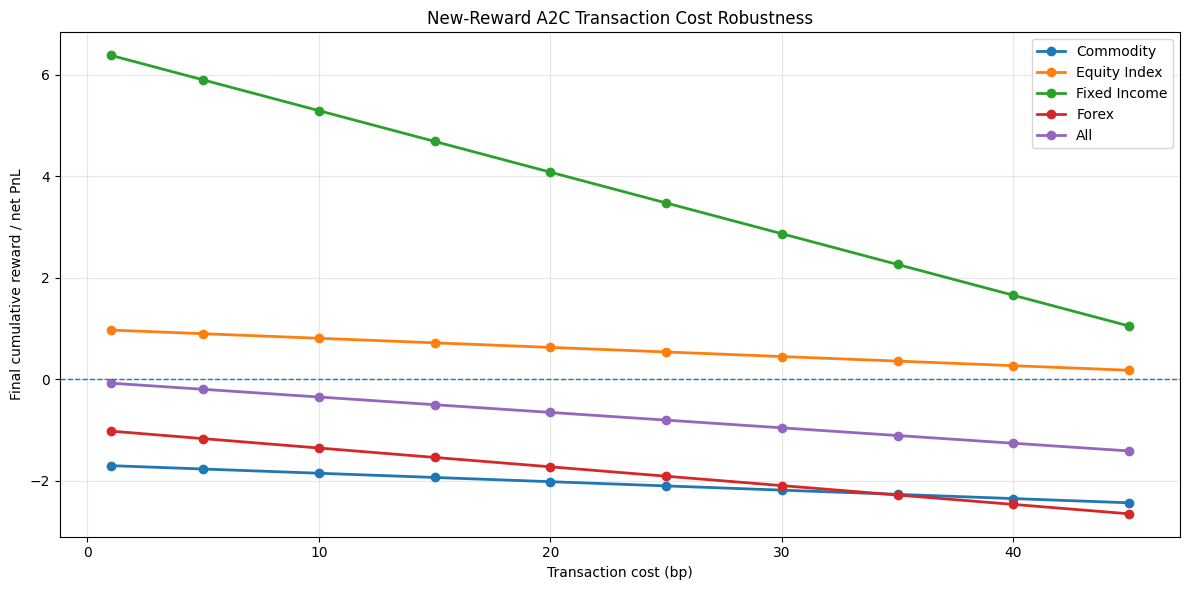

In [22]:
asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]

plt.figure(figsize=(12, 6))

for asset in asset_order:
    if asset not in tc_summary_wide.columns:
        continue
    plt.plot(
        tc_summary_wide["cost_bp"],
        tc_summary_wide[asset],
        marker="o",
        linewidth=2,
        label=asset,
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("New-Reward A2C Transaction Cost Robustness")
plt.xlabel("Transaction cost (bp)")
plt.ylabel("Final cumulative reward / net PnL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

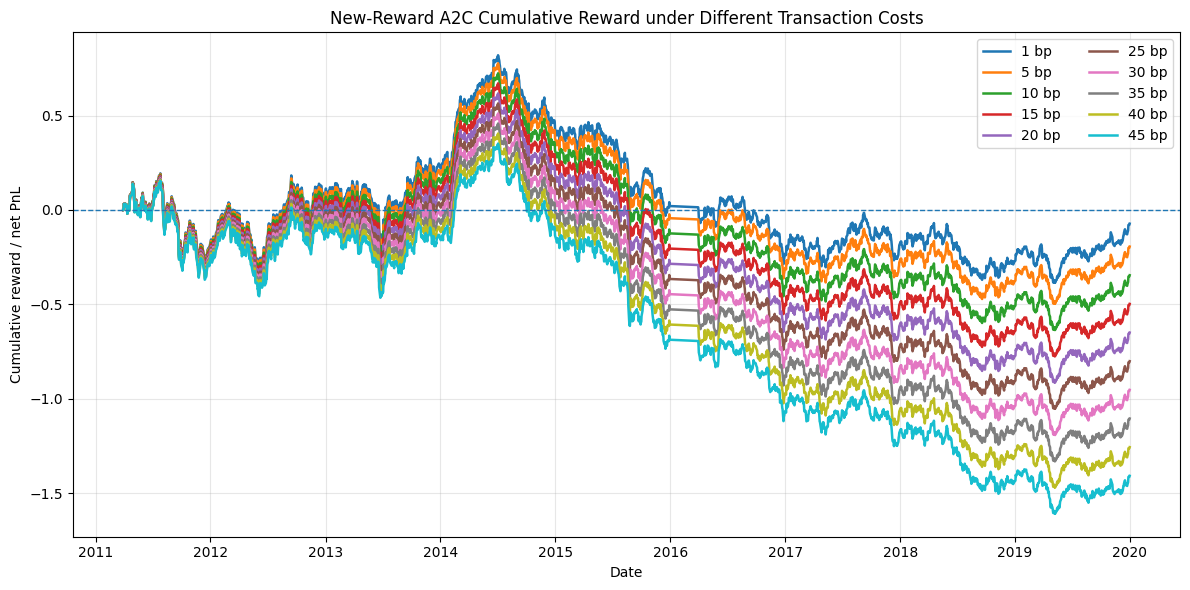

In [23]:
plt.figure(figsize=(12, 6))

for cost_bp in TC_BPS:
    dates, curve = tc_robustness_curves[cost_bp].get("All", (None, None))
    if dates is None or curve is None:
        continue

    s = pd.Series(curve, index=pd.to_datetime(dates)).sort_index()
    plt.plot(s.index, s.values, linewidth=1.8, label=f"{cost_bp} bp")

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("New-Reward A2C Cumulative Reward under Different Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative reward / net PnL")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Transaction cost robustness: Sharpe ratio and CSV outputs

This cell uses the same fixed new-reward A2C signals and recomputes daily `net_pnl` for each transaction-cost level. It saves the final cumulative reward and annualized Sharpe ratio by asset class.

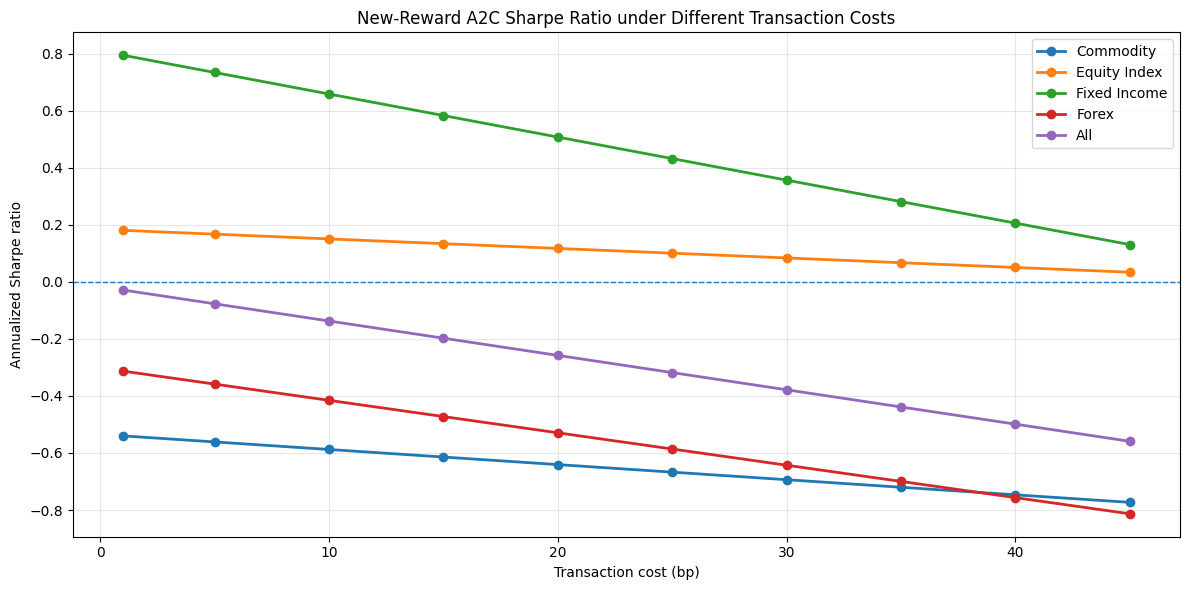

Saved CSV files:
- new_reward_a2c_tc_final_cumulative_reward_by_asset.csv
- new_reward_a2c_tc_sharpe_by_asset.csv
- new_reward_a2c_tc_final_cumulative_reward_by_asset_wide.csv
- new_reward_a2c_tc_sharpe_by_asset_wide.csv


asset_class,cost_bp,All,Commodity,Equity Index,Fixed Income,Forex
0,1,-0.028843,-0.540079,0.180369,0.794155,-0.313066
1,5,-0.077083,-0.561259,0.167032,0.733767,-0.358599
2,10,-0.137375,-0.587734,0.150360,0.658286,-0.415499
3,15,-0.197654,-0.614210,0.133687,0.582815,-0.472379
4,20,-0.257922,-0.640686,0.117013,0.507361,-0.529238
5,25,-0.318176,-0.667163,0.100339,0.431930,-0.586074
6,30,-0.378415,-0.693640,0.083664,0.356530,-0.642886
7,35,-0.438639,-0.720118,0.066990,0.281165,-0.699672
8,40,-0.498845,-0.746596,0.050315,0.205843,-0.756431
9,45,-0.559034,-0.773074,0.033640,0.130569,-0.813161


In [24]:
asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]

reward_rows = []
sharpe_rows = []

for cost_bp in TC_BPS:
    bp_decimal = cost_bp / 10000.0
    asset_series = {asset: [] for asset in asset_order}

    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if "a2c_signal" not in df.columns:
            continue

        df_cost = compute_pnl(
            df=df.copy(),
            signal_col="a2c_signal",
            sigma_target=0.064,
            bp=bp_decimal,
            mu=MU,
            dropna=False,
        )

        if not all(c in df_cost.columns for c in ["date", "net_pnl"]):
            continue

        asset = ticker_to_asset1.get(ticker)
        if asset not in asset_series:
            continue

        s = pd.Series(df_cost["net_pnl"].values, index=pd.to_datetime(df_cost["date"])).sort_index()
        asset_series[asset].append(s)
        asset_series["All"].append(s)

    for asset in asset_order:
        if len(asset_series[asset]) == 0:
            final_reward = np.nan
            sharpe = np.nan
        else:
            port = pd.DataFrame(asset_series[asset]).T.sort_index().mean(axis=1)
            final_reward = float(port.fillna(0.0).cumsum().iloc[-1])
            port_clean = port.dropna()
            if len(port_clean) > 1 and port_clean.std(ddof=1) != 0:
                sharpe = float(port_clean.mean() / port_clean.std(ddof=1) * np.sqrt(252))
            else:
                sharpe = np.nan

        reward_rows.append({
            "cost_bp": cost_bp,
            "asset_class": asset,
            "final_cumulative_reward": final_reward,
        })
        sharpe_rows.append({
            "cost_bp": cost_bp,
            "asset_class": asset,
            "annualized_sharpe": sharpe,
        })

reward_by_asset = pd.DataFrame(reward_rows)
sharpe_by_asset = pd.DataFrame(sharpe_rows)

reward_by_asset_wide = reward_by_asset.pivot(index="cost_bp", columns="asset_class", values="final_cumulative_reward").reset_index()
sharpe_by_asset_wide = sharpe_by_asset.pivot(index="cost_bp", columns="asset_class", values="annualized_sharpe").reset_index()

reward_by_asset.to_csv("new_reward_a2c_tc_final_cumulative_reward_by_asset.csv", index=False)
sharpe_by_asset.to_csv("new_reward_a2c_tc_sharpe_by_asset.csv", index=False)
reward_by_asset_wide.to_csv("new_reward_a2c_tc_final_cumulative_reward_by_asset_wide.csv", index=False)
sharpe_by_asset_wide.to_csv("new_reward_a2c_tc_sharpe_by_asset_wide.csv", index=False)

plt.figure(figsize=(12, 6))
for asset in asset_order:
    if asset not in sharpe_by_asset_wide.columns:
        continue
    plt.plot(
        sharpe_by_asset_wide["cost_bp"],
        sharpe_by_asset_wide[asset],
        marker="o",
        linewidth=2,
        label=asset,
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("New-Reward A2C Sharpe Ratio under Different Transaction Costs")
plt.xlabel("Transaction cost (bp)")
plt.ylabel("Annualized Sharpe ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Saved CSV files:")
print("- new_reward_a2c_tc_final_cumulative_reward_by_asset.csv")
print("- new_reward_a2c_tc_sharpe_by_asset.csv")
print("- new_reward_a2c_tc_final_cumulative_reward_by_asset_wide.csv")
print("- new_reward_a2c_tc_sharpe_by_asset_wide.csv")

sharpe_by_asset_wide

#### A2C comparison with Paper Table 3

This cell compares the new-reward A2C results with the A2C rows in Table 3: Experiment Results for the Raw Signal.

In [25]:
table3_a2c_compare_wide = build_a2c_table3_comparison_wide(
    pnl_by_ticker=pnl_a2c_by_ticker,
    ticker_to_asset=ticker_to_asset1,
    cost_bp=20,                 # 20 bp = 0.0020, the baseline cost used in the paper-style setup
    signal_col="a2c_signal",
    sigma_target=0.064,
    mu=MU,
    annualization=252,
)

table3_a2c_compare_wide.to_csv("new_reward_a2c_table3_raw_signal_a2c_comparison_wide.csv", index=False)
table3_a2c_compare_wide

,metric,cost_bp,Commodity Project A2C,Commodity Paper Table 3 A2C,Commodity Difference,Equity Index Project A2C,Equity Index Paper Table 3 A2C,Equity Index Difference,Fixed Income Project A2C,Fixed Income Paper Table 3 A2C,Fixed Income Difference,Forex Project A2C,Forex Paper Table 3 A2C,Forex Difference,All Project A2C,All Paper Table 3 A2C,All Difference
0,E(R),20,-0.237044,0.072,-0.309044,0.072447,0.293,-0.220553,0.468957,0.852,-0.383043,-0.196848,0.159,-0.355848,-0.074252,0.214,-0.288252
1,Std(R),20,0.369984,0.163,0.206984,0.619139,0.629,-0.009861,0.924307,1.345,-0.420693,0.371946,0.455,-0.083054,0.287885,0.221,0.066885
2,DD,20,0.248539,0.098,0.150539,0.495630,0.427,0.068630,0.602749,0.806,-0.203251,0.244629,0.267,-0.022371,0.200752,0.134,0.066752
3,Sharpe,20,-0.640686,0.440,-1.080686,0.117013,0.466,-0.348987,0.507361,0.633,-0.125639,-0.529238,0.349,-0.878238,-0.257922,0.969,-1.226922
4,Sortino,20,-0.953748,0.729,-1.682748,0.146172,0.686,-0.539828,0.778031,1.057,-0.278969,-0.804679,0.592,-1.396679,-0.369870,1.601,-1.970870
5,MDD,20,2.568264,0.099,2.469264,1.753087,0.193,1.560087,2.122332,0.128,1.994332,2.336701,0.081,2.255701,1.531488,0.009,1.522488
6,Calmar,20,-0.092297,0.161,-0.253297,0.041326,0.214,-0.172674,0.220963,0.397,-0.176037,-0.084242,0.193,-0.277242,-0.048484,0.672,-0.720484
7,% + Ret,20,0.496964,0.487,0.009964,0.496357,0.533,-0.036643,0.521878,0.517,0.004878,0.487517,0.507,-0.019483,0.505445,0.538,-0.032555
8,Ave P/L,20,0.911651,1.151,-0.239349,1.037295,0.965,0.072295,0.995269,1.039,-0.043731,0.962846,1.034,-0.071154,0.937381,1.014,-0.076619
